# Extension 1 - Energy Perspective: Fuel & CO₂ Savings from Flettner Rotor

## Goal
Estimate the **fuel consumption** and **CO₂ emissions** for the SC CONNECTOR vessel and quantify the savings achieved by the Norsepower 24v4 Flettner rotor.

## Methodology
| Step | Description |
|------|-------------|
| Ship resistance model | Cubic power law: `P_brake = k × V³` calibrated to operating point |
| Fuel model | SFOC × P_brake → fuel rate [t/h] |
| Rotor offset | P_engine_net = P_brake − P_rotor (where rotor is active) |
| CO₂ | Fuel × emission factor HFO (3.114 tCO₂/t) |
| CII | IMO Carbon Intensity Indicator delta with/without rotor |

## Assumptions
- Vessel displacement ≈ 3000 GT, DWT ≈ 3200 t (typical North Sea feeder container)
- P_rated ≈ 3500 kW at 11.5 kn (design speed)
- SFOC = 195 g/kWh (HFO/VLSFO, modern 4-stroke medium-speed diesel)
- AIS interval ≈ 7 min → dt = 7/60 h per observation
- Rotor polar: 1× Norsepower 24v4 (same as baseline model)

## 0. Setup

In [22]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH    = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Time range: {df['Time'].min()} → {df['Time'].max()}")
print(f"Voyages: {df['Voyage_ID'].nunique()}")
print(f"Mean SOG: {df['Speed_kn'].mean():.2f} kn")

Shape: (125160, 57)
Time range: 2023-02-02 00:06:00 → 2026-02-02 07:25:00
Voyages: 528
Mean SOG: 11.52 kn


## 1. Ship Resistance & Power Model

A simplified **cubic power law** relates brake power to speed:

$$P_{brake} [\text{kW}] = k_{resistance} \cdot V_{ms}^3$$

where $V_{ms}$ is Speed Over Ground converted to m/s. The constant $k_{resistance}$ is calibrated so that at design speed (11.5 kn) the engine delivers approximately 3500 kW - a realistic figure for a North Sea feeder container vessel of ~3000 GT.

This approximation is valid near the operating point. In reality, resistance includes form drag, wave-making, appendage, and weather components, but the cubic law captures the dominant propulsive power demand.

k_resistance = 16.9033 kW/(m/s)³

  Speed [kn]    P_brake [kW]
----------------------------
         8.0            1178
        10.0            2301
        11.5            3500
        13.0            5056
        15.0            7767
        17.0           11306


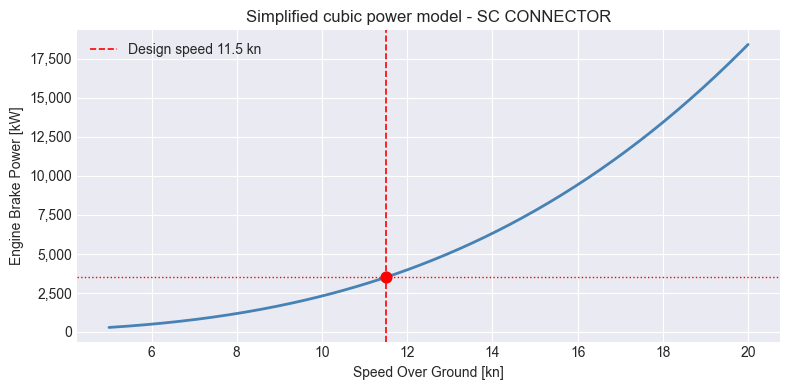

In [23]:
KN_TO_MS = 0.51444
P_DESIGN_KW  = 3500.0   # engine power at design speed [kW]
V_DESIGN_KN  = 11.5     # design speed [kn]

V_design_ms = V_DESIGN_KN * KN_TO_MS
k_resistance = P_DESIGN_KW / (V_design_ms ** 3)

def brake_power_kw(sog_kn):
    """Estimate engine brake power [kW] from SOG [kn] using cubic resistance law."""
    v_ms = np.asarray(sog_kn, dtype=float) * KN_TO_MS
    return k_resistance * v_ms ** 3

print(f"k_resistance = {k_resistance:.4f} kW/(m/s)³")
print()
print(f"{'Speed [kn]':>12}  {'P_brake [kW]':>14}")
print("-" * 28)
for v in [8, 10, 11.5, 13, 15, 17]:
    print(f"{v:>12.1f}  {brake_power_kw(v):>14.0f}")

# --- Power vs Speed curve ---
v_range = np.linspace(5, 20, 200)
p_range = brake_power_kw(v_range)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v_range, p_range, color='steelblue', linewidth=2)
ax.axvline(V_DESIGN_KN, color='red', linestyle='--', linewidth=1.2, label=f'Design speed {V_DESIGN_KN} kn')
ax.axhline(P_DESIGN_KW, color='red', linestyle=':', linewidth=1.0)
ax.scatter([V_DESIGN_KN], [P_DESIGN_KW], color='red', zorder=5, s=60)
ax.set_xlabel('Speed Over Ground [kn]')
ax.set_ylabel('Engine Brake Power [kW]')
ax.set_title('Simplified cubic power model - SC CONNECTOR')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 2. Fuel Consumption Model

**SFOC** (Specific Fuel Oil Consumption) converts engine power to fuel mass flow:

$$\dot{m}_{fuel} [t/h] = \frac{SFOC [g/kWh] \times P_{brake} [kW]}{10^6}$$

With rotor assistance the engine net power is reduced:

$$P_{net} = \max(P_{brake} - P_{rotor},\; 0)$$

Assumptions:
- SFOC = 195 g/kWh (HFO/VLSFO, modern 4-stroke medium-speed diesel at MCR)
- Engine efficiency is assumed constant across the load range considered (conservative)
- Rotor power directly offsets propulsive demand (100% shaft efficiency assumed)

In [24]:
SFOC_G_KWH = 195.0      # g/kWh
EF_HFO     = 3.114      # tCO₂ per t HFO (IMO default)
DT_HOURS   = 7.0 / 60   # AIS interval ≈ 7 min

def fuel_rate_t_h(power_kw):
    """Fuel consumption rate [t/h] from engine power [kW]."""
    return SFOC_G_KWH * np.maximum(power_kw, 0) / 1e6

print(f"SFOC:            {SFOC_G_KWH} g/kWh")
print(f"CO₂ factor HFO:  {EF_HFO} tCO₂/t")
print(f"AIS interval:    {DT_HOURS*60:.1f} min → dt = {DT_HOURS:.4f} h")
print()
print(f"Fuel rate at design speed (no rotor): {fuel_rate_t_h(P_DESIGN_KW)*24:.2f} t/day")

SFOC:            195.0 g/kWh
CO₂ factor HFO:  3.114 tCO₂/t
AIS interval:    7.0 min → dt = 0.1167 h

Fuel rate at design speed (no rotor): 16.38 t/day


## 3. Rotor Polar Diagram (Norsepower 24v4)

Power contribution from 1× 24v4 Flettner rotor as a function of True Wind Speed and wind angle from bow (absolute, 0°–180°). Values in [kW]; negative = drag.

Rotor polar sanity checks:
  10 m/s, α=90° (abeam):    144 kW
  10 m/s, α=0°  (headwind): -8 kW
  24 m/s, α=80° (max):      890 kW


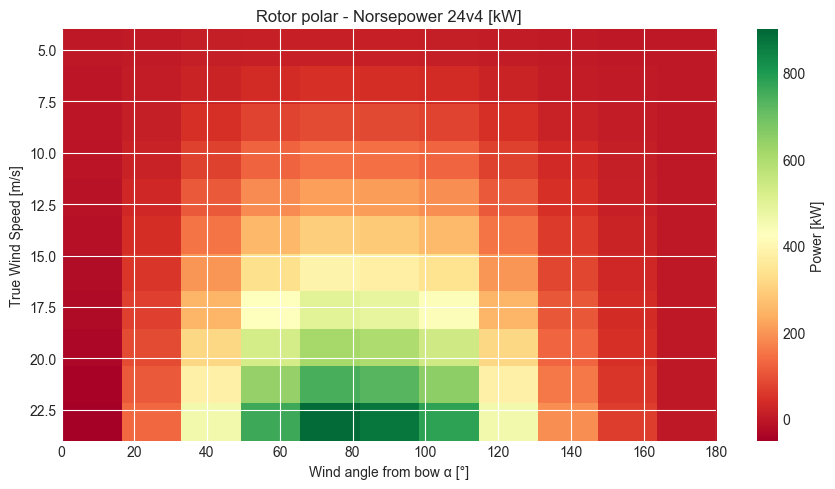

In [25]:
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])
KW_PER_KN = 200.0

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE,
    method='linear', bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)

def rotor_active_mask(wind_ms, alpha_abs, hs):
    power = rotor_power_kw(wind_ms, alpha_abs)
    return (power > 0) & (np.asarray(hs) <= 6.0) & (np.asarray(wind_ms) <= 42.0)

print("Rotor polar sanity checks:")
print(f"  10 m/s, α=90° (abeam):    {rotor_power_kw(10, 90):.0f} kW")
print(f"  10 m/s, α=0°  (headwind): {rotor_power_kw(10, 0):.0f} kW")
print(f"  24 m/s, α=80° (max):      {rotor_power_kw(24, 80):.0f} kW")

# Heatmap of polar
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(POWER_TABLE, cmap='RdYlGn', aspect='auto',
               vmin=-50, vmax=900,
               extent=[WIND_ANGLES[0], WIND_ANGLES[-1], WIND_SPEEDS[-1], WIND_SPEEDS[0]])
ax.set_xlabel('Wind angle from bow α [°]')
ax.set_ylabel('True Wind Speed [m/s]')
ax.set_title('Rotor polar - Norsepower 24v4 [kW]')
plt.colorbar(im, ax=ax, label='Power [kW]')
plt.tight_layout()
plt.show()

## 4. Apply to Full Dataset

Compute row-by-row engine power, fuel rate, and rotor contribution for all 125k observations.

In [26]:
df['P_brake_kw']         = brake_power_kw(df['Speed_kn'].values)

p_rotor_raw              = rotor_power_kw(df['True_Wind_Speed_ms'].values, df['alpha_abs_deg'].values)
active                   = rotor_active_mask(df['True_Wind_Speed_ms'].values,
                                              df['alpha_abs_deg'].values,
                                              df['H_s'].values)
df['P_rotor_kw']         = np.where(active, p_rotor_raw, 0.0)
df['P_engine_net_kw']    = np.maximum(df['P_brake_kw'] - df['P_rotor_kw'], 0.0)
df['delta_P_kw']         = df['P_brake_kw'] - df['P_engine_net_kw']

df['fuel_rate_base']     = fuel_rate_t_h(df['P_brake_kw'].values)       # t/h
df['fuel_rate_rotor']    = fuel_rate_t_h(df['P_engine_net_kw'].values)  # t/h
df['delta_fuel_t_h']     = df['fuel_rate_base'] - df['fuel_rate_rotor']
df['delta_co2_t_h']      = df['delta_fuel_t_h'] * EF_HFO

total_fuel_base   = (df['fuel_rate_base']  * DT_HOURS).sum()
total_fuel_rotor  = (df['fuel_rate_rotor'] * DT_HOURS).sum()
total_co2_saved   = (df['delta_co2_t_h']   * DT_HOURS).sum()
total_co2_base    = total_fuel_base * EF_HFO

print(f"{'='*55}")
print(f"FULL DATASET ENERGY SUMMARY")
print(f"{'='*55}")
print(f"Total observations:           {len(df):>10,}")
print(f"Rotor active share:           {active.mean()*100:>9.1f}%")
print(f"Mean P_brake:                 {df['P_brake_kw'].mean():>9.0f} kW")
print(f"Mean P_rotor (when active):   {df.loc[active, 'P_rotor_kw'].mean():>9.1f} kW")
print(f"")
print(f"Total fuel (baseline):        {total_fuel_base:>9.1f} t")
print(f"Total fuel (with rotor):      {total_fuel_rotor:>9.1f} t")
print(f"Fuel saved:                   {total_fuel_base-total_fuel_rotor:>9.1f} t  ({(total_fuel_base-total_fuel_rotor)/total_fuel_base*100:.2f}%)")
print(f"")
print(f"Total CO₂ (baseline):         {total_co2_base:>9.1f} t")
print(f"CO₂ saved:                    {total_co2_saved:>9.1f} t")
print(f"CO₂ saving rate:              {total_co2_saved/total_co2_base*100:>9.2f}%")

FULL DATASET ENERGY SUMMARY
Total observations:              125,160
Rotor active share:                97.6%
Mean P_brake:                      3887 kW
Mean P_rotor (when active):        40.4 kW

Total fuel (baseline):          11066.7 t
Total fuel (with rotor):        10954.4 t
Fuel saved:                       112.2 t  (1.01%)

Total CO₂ (baseline):           34461.6 t
CO₂ saved:                        349.4 t
CO₂ saving rate:                   1.01%


## 5. Voyage-Level Analysis

Aggregate fuel and CO₂ savings per voyage to understand operational variability.

Voyage-level stats (top 10 by CO₂ savings):
 Voyage_ID  voyage_distance_nm  fuel_baseline_t  fuel_savings_t  pct_saving  co2_savings_t
       525             1207.28            96.80            2.31        2.39           7.20
       456              676.02            41.51            1.73        4.17           5.39
       474              674.93            46.66            1.31        2.80           4.07
       505             1121.62            72.93            1.29        1.76           4.01
       357              561.90            33.49            1.26        3.76           3.92
       194              543.25            28.41            1.09        3.82           3.38
       364              871.80            56.10            1.08        1.92           3.36
       344              807.46            52.88            1.07        2.03           3.35
       527              646.99            53.00            1.02        1.93           3.18
       528              638.75            53.8

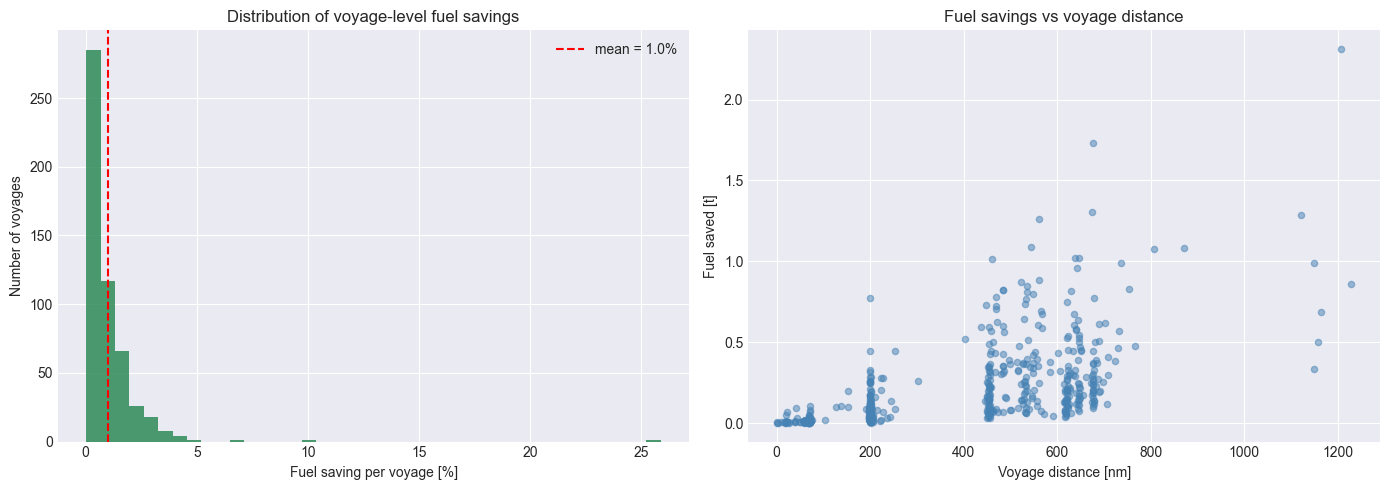

In [27]:
df['fuel_base_per_obs']  = df['fuel_rate_base']  * DT_HOURS
df['fuel_rotor_per_obs'] = df['fuel_rate_rotor'] * DT_HOURS
df['co2_saved_per_obs']  = df['delta_co2_t_h']   * DT_HOURS

voyage_grp = df.groupby('Voyage_ID')

voyage_stats = voyage_grp.agg(
    fuel_baseline_t  = ('fuel_base_per_obs',  'sum'),
    fuel_with_rotor_t= ('fuel_rotor_per_obs', 'sum'),
    co2_savings_t    = ('co2_saved_per_obs',  'sum'),
    n_points         = ('Speed_kn',           'count'),
    dist_start_nm    = ('Total_dist_nm',       'first'),
    dist_end_nm      = ('Total_dist_nm',       'last'),
).reset_index()

voyage_stats['fuel_savings_t']    = voyage_stats['fuel_baseline_t'] - voyage_stats['fuel_with_rotor_t']
voyage_stats['pct_saving']        = voyage_stats['fuel_savings_t'] / voyage_stats['fuel_baseline_t'] * 100
voyage_stats['voyage_distance_nm']= voyage_stats['dist_end_nm'] - voyage_stats['dist_start_nm']
voyage_stats['specific_co2_kg_nm']= voyage_stats['co2_savings_t'] * 1000 / voyage_stats['voyage_distance_nm'].clip(lower=1)

print("Voyage-level stats (top 10 by CO₂ savings):")
cols = ['Voyage_ID', 'voyage_distance_nm', 'fuel_baseline_t', 'fuel_savings_t', 'pct_saving', 'co2_savings_t']
print(voyage_stats.sort_values('co2_savings_t', ascending=False)[cols].head(10).round(2).to_string(index=False))

print(f"\nMedian voyage fuel saving: {voyage_stats['pct_saving'].median():.2f}%")
print(f"Mean voyage fuel saving:   {voyage_stats['pct_saving'].mean():.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(voyage_stats['pct_saving'], bins=40, color='seagreen', edgecolor='none', alpha=0.85)
axes[0].axvline(voyage_stats['pct_saving'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"mean = {voyage_stats['pct_saving'].mean():.1f}%")
axes[0].set_xlabel('Fuel saving per voyage [%]')
axes[0].set_ylabel('Number of voyages')
axes[0].set_title('Distribution of voyage-level fuel savings')
axes[0].legend()

axes[1].scatter(voyage_stats['voyage_distance_nm'], voyage_stats['fuel_savings_t'],
                alpha=0.5, s=20, color='steelblue')
axes[1].set_xlabel('Voyage distance [nm]')
axes[1].set_ylabel('Fuel saved [t]')
axes[1].set_title('Fuel savings vs voyage distance')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'voyage_fuel_savings.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Annual Projection

Scale total savings over the dataset period to a 1-year operational estimate.

In [28]:
dataset_days   = (df['Time'].max() - df['Time'].min()).total_seconds() / 86400
dataset_years  = dataset_days / 365.25

annual_fuel_base_t  = total_fuel_base  / dataset_years
annual_fuel_rotor_t = total_fuel_rotor / dataset_years
annual_fuel_saved_t = (total_fuel_base - total_fuel_rotor) / dataset_years
annual_co2_saved_t  = total_co2_saved  / dataset_years
annual_co2_base_t   = total_co2_base   / dataset_years

print(f"Dataset duration:            {dataset_days:.0f} days  ({dataset_years:.2f} years)")
print()
print(f"{'ANNUAL PROJECTION':^50}")
print(f"{'='*50}")
print(f"{'Metric':<35} {'Value':>14}")
print(f"{'-'*50}")
print(f"{'Annual fuel (baseline)':<35} {annual_fuel_base_t:>11.0f} t")
print(f"{'Annual fuel (with rotor)':<35} {annual_fuel_rotor_t:>11.0f} t")
print(f"{'Annual fuel saved':<35} {annual_fuel_saved_t:>11.1f} t")
print(f"{'Fuel saving (%)':<35} {annual_fuel_saved_t/annual_fuel_base_t*100:>10.2f}%")
print(f"{'-'*50}")
print(f"{'Annual CO₂ (baseline)':<35} {annual_co2_base_t:>11.0f} t")
print(f"{'Annual CO₂ saved':<35} {annual_co2_saved_t:>11.1f} t")
print(f"{'CO₂ saving (%)':<35} {annual_co2_saved_t/annual_co2_base_t*100:>10.2f}%")
print(f"{'='*50}")

Dataset duration:            1096 days  (3.00 years)

                ANNUAL PROJECTION                 
Metric                                       Value
--------------------------------------------------
Annual fuel (baseline)                     3687 t
Annual fuel (with rotor)                   3650 t
Annual fuel saved                          37.4 t
Fuel saving (%)                           1.01%
--------------------------------------------------
Annual CO₂ (baseline)                     11481 t
Annual CO₂ saved                          116.4 t
CO₂ saving (%)                            1.01%


## 7. CII - IMO Carbon Intensity Indicator

The **CII** measures the CO₂ intensity of a voyage per unit of transport work:

$$CII = \frac{CO_2 \text{ emitted [g]}}{DWT \times \text{distance [nm]}}$$

We compute the annual attained CII with and without rotor, and show the improvement. Exact rating boundaries (A–E) depend on vessel type and reference lines from IMO MEPC.338(76) - we show the delta here.

**Reference:** For a general cargo/feeder container, a CII of ~8–12 g/t·nm is typical of 2023 operating conditions.

In [29]:
DWT_T = 3200.0  # deadweight tonnage estimate for SC CONNECTOR class

# Total voyage distance covered in the dataset
total_distance_nm = voyage_stats['voyage_distance_nm'].clip(lower=0).sum()
annual_distance_nm = total_distance_nm / dataset_years

# Total CO₂ emitted in the dataset period
total_co2_base_t  = total_fuel_base * EF_HFO
total_co2_rotor_t = total_fuel_rotor * EF_HFO

annual_co2_base_g  = annual_co2_base_t  * 1e6  # g
annual_co2_rotor_g = (total_co2_rotor_t / dataset_years) * 1e6

CII_baseline = annual_co2_base_g  / (DWT_T * annual_distance_nm)
CII_rotor    = annual_co2_rotor_g / (DWT_T * annual_distance_nm)
CII_delta    = CII_baseline - CII_rotor
CII_pct      = CII_delta / CII_baseline * 100

print(f"{'CII ANALYSIS':^52}")
print(f"{'='*52}")
print(f"DWT:                        {DWT_T:>8.0f} t")
print(f"Annual distance:            {annual_distance_nm:>8,.0f} nm")
print(f"")
print(f"Attained CII (no rotor):    {CII_baseline:>8.2f} g CO₂/(t·nm)")
print(f"Attained CII (with rotor):  {CII_rotor:>8.2f} g CO₂/(t·nm)")
print(f"CII improvement:            {CII_delta:>8.2f} g CO₂/(t·nm)  ({CII_pct:.2f}%)")
print(f"{'='*52}")
print(f"\nNote: Exact A–E rating requires the IMO Reference Line")
print(f"for this vessel type and size (MEPC.338(76)).")
print(f"For general cargo (feeder), a delta of ~{CII_pct:.1f}% can")
print(f"shift a vessel one rating band (e.g., C→B).")

                    CII ANALYSIS                    
DWT:                            3200 t
Annual distance:              66,755 nm

Attained CII (no rotor):       53.75 g CO₂/(t·nm)
Attained CII (with rotor):     53.20 g CO₂/(t·nm)
CII improvement:                0.54 g CO₂/(t·nm)  (1.01%)

Note: Exact A–E rating requires the IMO Reference Line
for this vessel type and size (MEPC.338(76)).
For general cargo (feeder), a delta of ~1.0% can
shift a vessel one rating band (e.g., C→B).


## 8. Summary Plot

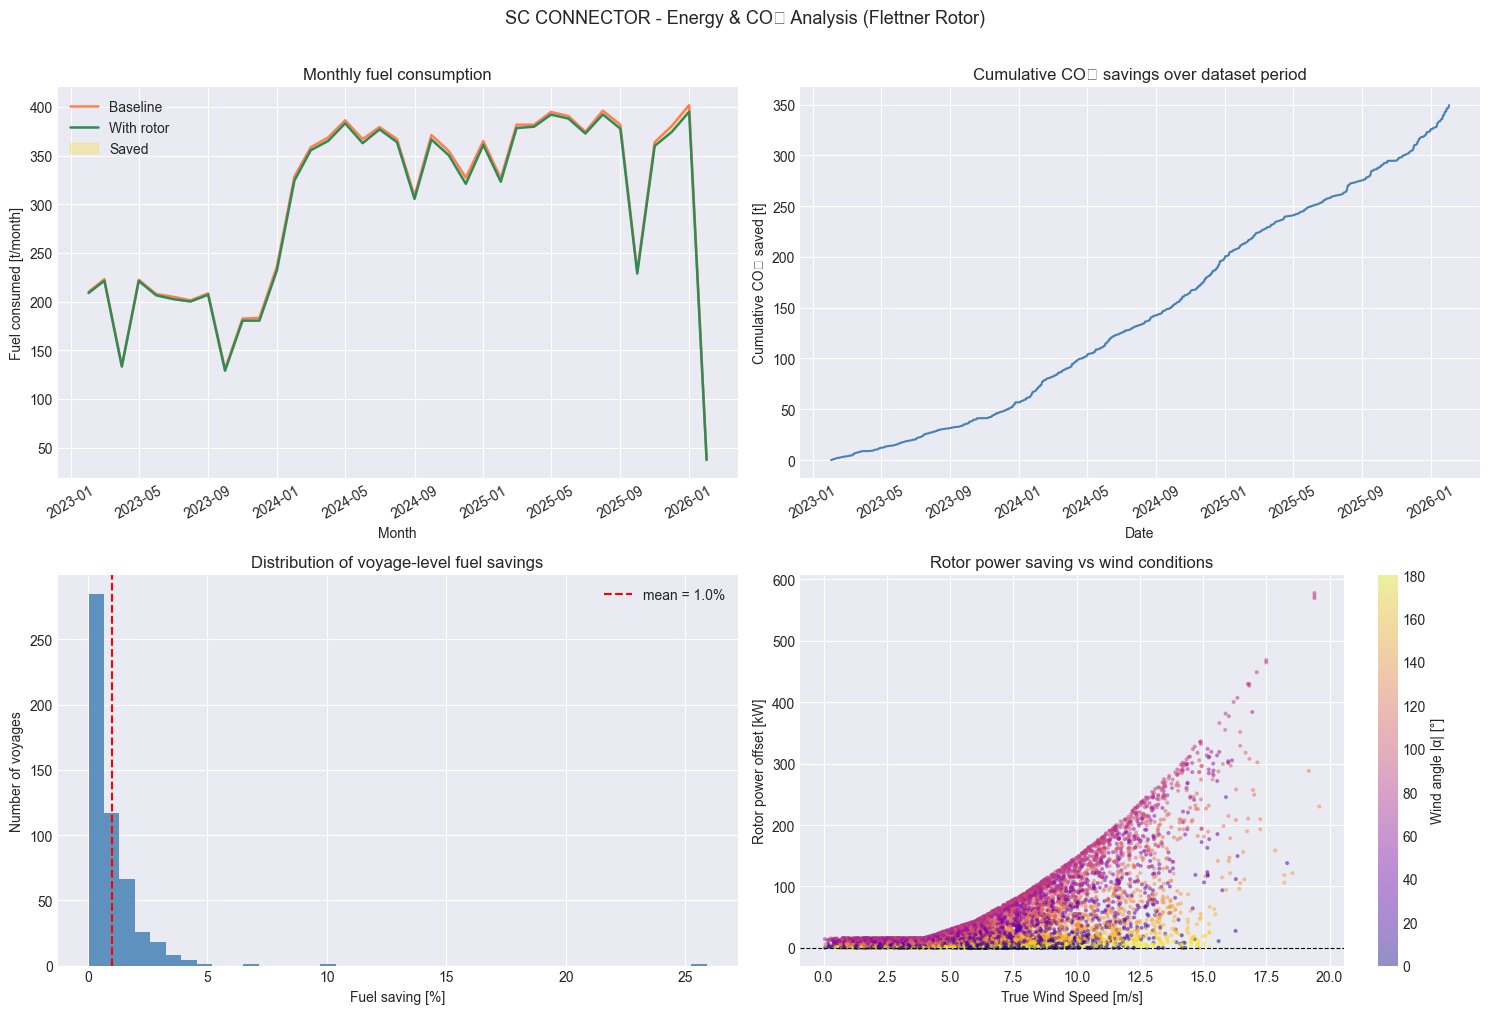

In [30]:
df['YearMonth'] = df['Time'].dt.to_period('M')

monthly = df.groupby('YearMonth').agg(
    fuel_base_month  = ('fuel_base_per_obs',  'sum'),
    fuel_rotor_month = ('fuel_rotor_per_obs', 'sum'),
    co2_saved_month  = ('co2_saved_per_obs',  'sum'),
).reset_index()
monthly['date'] = monthly['YearMonth'].dt.to_timestamp()

# Cumulative CO₂ saved (sorted by time)
df_sorted = df.sort_values('Time')
df_sorted['cum_co2_saved'] = df_sorted['co2_saved_per_obs'].cumsum()

# Scatter sample for panel 4
sample_idx = np.random.choice(len(df), size=min(8000, len(df)), replace=False)
df_sample  = df.iloc[sample_idx]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Monthly fuel rate
ax = axes[0, 0]
ax.plot(monthly['date'], monthly['fuel_base_month'], color='coral', linewidth=1.8, label='Baseline')
ax.plot(monthly['date'], monthly['fuel_rotor_month'], color='seagreen', linewidth=1.8, label='With rotor')
ax.fill_between(monthly['date'],
                monthly['fuel_rotor_month'], monthly['fuel_base_month'],
                alpha=0.25, color='gold', label='Saved')
ax.set_xlabel('Month')
ax.set_ylabel('Fuel consumed [t/month]')
ax.set_title('Monthly fuel consumption')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Panel 2: Cumulative CO₂ saved
ax = axes[0, 1]
ax.plot(df_sorted['Time'], df_sorted['cum_co2_saved'], color='steelblue', linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative CO₂ saved [t]')
ax.set_title('Cumulative CO₂ savings over dataset period')
ax.tick_params(axis='x', rotation=30)

# Panel 3: Histogram of voyage % fuel savings
ax = axes[1, 0]
ax.hist(voyage_stats['pct_saving'], bins=40, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(voyage_stats['pct_saving'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"mean = {voyage_stats['pct_saving'].mean():.1f}%")
ax.set_xlabel('Fuel saving [%]')
ax.set_ylabel('Number of voyages')
ax.set_title('Distribution of voyage-level fuel savings')
ax.legend()

# Panel 4: Rotor power vs wind speed, coloured by wind angle
ax = axes[1, 1]
sc = ax.scatter(df_sample['True_Wind_Speed_ms'], df_sample['P_rotor_kw'],
                c=df_sample['alpha_abs_deg'], cmap='plasma',
                s=4, alpha=0.4, vmin=0, vmax=180)
plt.colorbar(sc, ax=ax, label='Wind angle |α| [°]')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('True Wind Speed [m/s]')
ax.set_ylabel('Rotor power offset [kW]')
ax.set_title('Rotor power saving vs wind conditions')

plt.suptitle('SC CONNECTOR - Energy & CO₂ Analysis (Flettner Rotor)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'energy_fuel_co2.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Summary

In [31]:
print("="*60)
print("ENERGY & CO₂ SUMMARY - SC CONNECTOR + 1× Norsepower 24v4")
print("="*60)
print(f"Dataset: {df['Time'].min().date()} → {df['Time'].max().date()}")
print(f"         ({dataset_years:.2f} years, {len(df):,} observations)")
print()
print(f"SHIP MODEL")
print(f"  Power at design speed (11.5 kn): {P_DESIGN_KW:,.0f} kW")
print(f"  k_resistance:                    {k_resistance:.4f} kW/(m/s)³")
print(f"  SFOC:                            {SFOC_G_KWH} g/kWh")
print()
print(f"DATASET TOTALS")
print(f"  Fuel (baseline):   {total_fuel_base:>8,.0f} t")
print(f"  Fuel (rotor):      {total_fuel_rotor:>8,.0f} t")
print(f"  Fuel saved:        {total_fuel_base-total_fuel_rotor:>8,.1f} t   ({(total_fuel_base-total_fuel_rotor)/total_fuel_base*100:.2f}%)")
print(f"  CO₂ saved:         {total_co2_saved:>8,.1f} t")
print()
print(f"ANNUALISED")
print(f"  Annual fuel saved: {annual_fuel_saved_t:>8,.0f} t/year")
print(f"  Annual CO₂ saved:  {annual_co2_saved_t:>8,.0f} t/year")
print()
print(f"CII")
print(f"  CII (no rotor):    {CII_baseline:.2f} g CO₂/(t·nm)")
print(f"  CII (with rotor):  {CII_rotor:.2f} g CO₂/(t·nm)")
print(f"  CII improvement:   {CII_pct:.2f}%")
print("="*60)

ENERGY & CO₂ SUMMARY - SC CONNECTOR + 1× Norsepower 24v4
Dataset: 2023-02-02 → 2026-02-02
         (3.00 years, 125,160 observations)

SHIP MODEL
  Power at design speed (11.5 kn): 3,500 kW
  k_resistance:                    16.9033 kW/(m/s)³
  SFOC:                            195.0 g/kWh

DATASET TOTALS
  Fuel (baseline):     11,067 t
  Fuel (rotor):        10,954 t
  Fuel saved:           112.2 t   (1.01%)
  CO₂ saved:            349.4 t

ANNUALISED
  Annual fuel saved:       37 t/year
  Annual CO₂ saved:       116 t/year

CII
  CII (no rotor):    53.75 g CO₂/(t·nm)
  CII (with rotor):  53.20 g CO₂/(t·nm)
  CII improvement:   1.01%
